[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/langchain-ai/langchain-academy/blob/main/module-2/trim-filter-messages.ipynb) [![Open in LangChain Academy](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e9eba12c7b7688aa3dbb5e_LCA-badge-green.svg)](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58239435-lesson-4-trim-and-filter-messages)

# Filtering and trimming messages

## Review

Now, we have a deeper understanding of a few things: 

* How to customize the graph state schema
* How to define custom state reducers
* How to use multiple graph state schemas

## Goals

Now, we can start using these concepts with models in LangGraph!
 
In the next few sessions, we'll build towards a chatbot that has long-term memory.

Because our chatbot will use messages, let's first talk a bit more about advanced ways to work with messages in graph state.

In [ ]:
%%capture --no-stderr
%pip install --quiet -U langchain_core langgraph langchain_openai

In [1]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("OPENAI_API_KEY")

We'll use [LangSmith](https://docs.langchain.com/langsmith/home) for [tracing](https://docs.langchain.com/langsmith/observability-concepts).

We'll log to a project, `langchain-academy`. 

In [2]:
_set_env("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "langchain-academy"

LANGSMITH_API_KEY:  ········


## Messages as state

First, let's define some messages.

In [4]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage

messages = [AIMessage(f"So you said you were studying French but youre basic level, right?", name="Bot")]
messages.append(HumanMessage(f"Yes, I took only 2 classes so far, how can I improve in a good way ?", name="Murilo"))

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you said you were studying French but youre basic level, right?
================================ Human Message =================================
Name: Murilo

Yes, I took only 2 classes so far, how can I improve in a good way ?


Recall we can pass them to a chat model.

In [5]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-3.5-turbo-0125")
llm.invoke(messages)

AIMessage(content="To improve your French skills in a meaningful way, you can try the following strategies:\n\n1. Practice regularly: Consistency is key when it comes to learning a new language. Set aside some time each day to practice your French, whether it's through studying, speaking with native speakers, or using language learning apps.\n\n2. Immerse yourself in the language: Try to surround yourself with French as much as possible. Listen to French music, watch French movies or TV shows, and read French books or articles. Immersing yourself in the language can help you pick up new vocabulary and improve your pronunciation.\n\n3. Practice speaking with others: One of the best ways to improve your speaking skills is by engaging in conversations with native speakers. Look for language exchange partners, join language exchange meetups, or take conversational French classes. Speaking regularly will help you gain confidence and fluency in French.\n\n4. Use language learning resources: 

We can run our chat model in a simple graph with `MessagesState`.

In [7]:
from IPython.display import Image, display
from langgraph.graph import MessagesState
from langgraph.graph import StateGraph, START, END

In [8]:
# Node
def chat_model_node(state: MessagesState):
    return {"messages": llm.invoke(state["messages"])}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

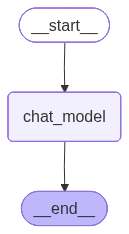

In [9]:
# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [12]:
output = graph.invoke({'messages': messages})
for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you said you were studying French but youre basic level, right?
================================ Human Message =================================
Name: Murilo

Yes, I took only 2 classes so far, how can I improve in a good way ?
================================== Ai Message ==================================

That's great! Here are a few tips that can help you improve your French in a good way:

1. Practice regularly: Try to study a little bit every day. Consistent practice is key to language learning.

2. Immerse yourself in the language: Watch French movies or TV shows, listen to French music, and read books or articles in French. Immersing yourself in the language can help improve your comprehension and vocabulary.

3. Use language learning apps: There are many language learning apps available that can help you practice your French skills. Duolingo, Babbel, and Rosetta Stone are popular opt

## Reducer

A practical challenge when working with messages is managing long-running conversations. 

Long-running conversations result in high token usage and latency if we are not careful, because we pass a growing list of messages to the model.

We have a few ways to address this.

First, recall the trick we saw using `RemoveMessage` and the `add_messages` reducer.

In [13]:
from langchain_core.messages import RemoveMessage

# Nodes
def filter_messages(state: MessagesState):
    # Delete all but the 2 most recent messages
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"messages": delete_messages}

def chat_model_node(state: MessagesState):    
    return {"messages": [llm.invoke(state["messages"])]}

In [14]:
# Build graph
builder = StateGraph(MessagesState)
builder.add_node("filter", filter_messages)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "filter")
builder.add_edge("filter", "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

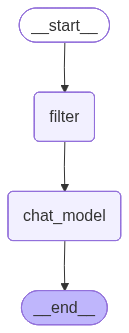

In [15]:
# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [16]:
# Message list with a preamble
messages = [AIMessage("Hi.", name="Bot", id="1")]
messages.append(HumanMessage("Hi.", name="Murilo", id="2"))
messages.append(AIMessage("So you said you were researching about simple words in French?", name="Bot", id="3"))
messages.append(HumanMessage("Yes, I'm studying but i had only 2 classes so far, can you give me important words?", name="Murilo", id="4"))

In [17]:
# Invoke
output = graph.invoke({'messages': messages})
for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you said you were researching about simple words in French?
================================ Human Message =================================
Name: Murilo

Yes, I'm studying but i had only 2 classes so far, can you give me important words?
================================== Ai Message ==================================

Of course! Here are some common and important words in French that may be helpful for your studies:

1. Bonjour - Hello
2. Merci - Thank you
3. Oui - Yes
4. Non - No
5. S'il vous plaît - Please
6. Excusez-moi - Excuse me
7. Merci beaucoup - Thank you very much
8. Au revoir - Goodbye
9. Salut - Hi/Bye (informal)
10. Bonne journée - Have a good day

These are just a few basic words and phrases to get you started. Practice them regularly and you'll become more comfortable with the language over time.


## Filtering messages

If you don't need or want to modify the graph state, you can just filter the messages you pass to the chat model.

For example, just pass in a filtered list: `llm.invoke(messages[-1:])` to the model.

In [23]:
# Node
def chat_model_node(state: MessagesState):
    return {"messages": [llm.invoke(state["messages"][-1:])]}

In [24]:
# Build graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

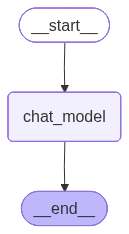

In [25]:
# View
display(Image(graph.get_graph().draw_mermaid_png()))

Let's take our existing list of messages, append the above LLM response, and append a follow-up question.

In [26]:
messages.append(output['messages'][-1])
messages.append(HumanMessage(f"Tell me more about Basic French Words!", name="Murilo"))

In [27]:
for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

Hi.
================================ Human Message =================================
Name: Murilo

Hi.
================================== Ai Message ==================================
Name: Bot

So you said you were researching about simple words in French?
================================ Human Message =================================
Name: Murilo

Yes, I'm studying but i had only 2 classes so far, can you give me important words?
================================== Ai Message ==================================

Of course! Here are some common and important words in French that may be helpful for your studies:

1. Bonjour - Hello
2. Merci - Thank you
3. Oui - Yes
4. Non - No
5. S'il vous plaît - Please
6. Excusez-moi - Excuse me
7. Merci beaucoup - Thank you very much
8. Au revoir - Goodbye
9. Salut - Hi/Bye (informal)
10. Bonne journée - Have a good day

These are just a few basic words and ph

In [28]:
# Invoke, using message filtering
output = graph.invoke({'messages': messages})
for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

Hi.
================================ Human Message =================================
Name: Murilo

Hi.
================================== Ai Message ==================================
Name: Bot

So you said you were researching about simple words in French?
================================ Human Message =================================
Name: Murilo

Yes, I'm studying but i had only 2 classes so far, can you give me important words?
================================== Ai Message ==================================

Of course! Here are some common and important words in French that may be helpful for your studies:

1. Bonjour - Hello
2. Merci - Thank you
3. Oui - Yes
4. Non - No
5. S'il vous plaît - Please
6. Excusez-moi - Excuse me
7. Merci beaucoup - Thank you very much
8. Au revoir - Goodbye
9. Salut - Hi/Bye (informal)
10. Bonne journée - Have a good day

These are just a few basic words and ph

The state has all of the mesages.

But, let's look at the LangSmith trace to see that the model invocation only uses the last message:

https://smith.langchain.com/public/75aca3ce-ef19-4b92-94be-0178c7a660d9/r

## Trim messages

Another approach is to [trim messages](https://docs.langchain.com/oss/python/langgraph/add-memory#trim-messages), based upon a set number of tokens. 

This restricts the message history to a specified number of tokens.

While filtering only returns a post-hoc subset of the messages between agents, trimming restricts the number of tokens that a chat model can use to respond.

See the `trim_messages` below.

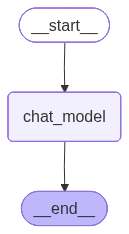

In [29]:
from langchain_core.messages import trim_messages

# Node
def chat_model_node(state: MessagesState):
    messages = trim_messages(
            state["messages"],
            max_tokens=100,
            strategy="last",
            token_counter=ChatOpenAI(model="gpt-3.5-turbo-0125"),
            allow_partial=False,
        )
    return {"messages": [llm.invoke(messages)]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [34]:
for i in messages:
 print(i)
 print("/n")

content='Hi.' additional_kwargs={} response_metadata={} name='Bot' id='1' tool_calls=[] invalid_tool_calls=[]
/n
content='Hi.' additional_kwargs={} response_metadata={} name='Murilo' id='2'
/n
content='So you said you were researching about simple words in French?' additional_kwargs={} response_metadata={} name='Bot' id='3' tool_calls=[] invalid_tool_calls=[]
/n
content="Yes, I'm studying but i had only 2 classes so far, can you give me important words?" additional_kwargs={} response_metadata={} name='Murilo' id='4'
/n
content="Of course! Here are some common and important words in French that may be helpful for your studies:\n\n1. Bonjour - Hello\n2. Merci - Thank you\n3. Oui - Yes\n4. Non - No\n5. S'il vous plaît - Please\n6. Excusez-moi - Excuse me\n7. Merci beaucoup - Thank you very much\n8. Au revoir - Goodbye\n9. Salut - Hi/Bye (informal)\n10. Bonne journée - Have a good day\n\nThese are just a few basic words and phrases to get you started. Practice them regularly and you'll bec

In [35]:
messages.append(output['messages'][-1])
messages.append(HumanMessage(f"Give me more tips", name="Murilo"))

In [41]:
# Example of trimming messages
trim_messages(
            messages,
            max_tokens=100,
            strategy="last",
            token_counter=ChatOpenAI(model="gpt-3.5-turbo-0125"),
            allow_partial=True
        )

[AIMessage(content='\nThere are also many resources available online and in language-learning books that can help you expand your vocabulary and practice using basic French words in context. Practicing regularly and immersing yourself in the language will help you become more proficient in French over time.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 174, 'prompt_tokens': 18, 'total_tokens': 192, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DUaxPdztRd7ruXyxYQ47TY7jdQBdm', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d8cd5-3241-7c00-8da7-1043587fb3aa-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 18, 'outp

In [38]:
# Example of trimming messages
trim_messages(
            messages,
            max_tokens=100,
            strategy="last",
            token_counter=ChatOpenAI(model="gpt-3.5-turbo-0125"),
            allow_partial=False
        )

[HumanMessage(content='Give me more tips', additional_kwargs={}, response_metadata={}, name='Murilo')]

In [42]:
# Invoke, using message trimming in the chat_model_node 
messages_out_trim = graph.invoke({'messages': messages})

In [43]:
for a in messages_out_trim['messages']:
    a.pretty_print()

================================== Ai Message ==================================
Name: Bot

Hi.
================================ Human Message =================================
Name: Murilo

Hi.
================================== Ai Message ==================================
Name: Bot

So you said you were researching about simple words in French?
================================ Human Message =================================
Name: Murilo

Yes, I'm studying but i had only 2 classes so far, can you give me important words?
================================== Ai Message ==================================

Of course! Here are some common and important words in French that may be helpful for your studies:

1. Bonjour - Hello
2. Merci - Thank you
3. Oui - Yes
4. Non - No
5. S'il vous plaît - Please
6. Excusez-moi - Excuse me
7. Merci beaucoup - Thank you very much
8. Au revoir - Goodbye
9. Salut - Hi/Bye (informal)
10. Bonne journée - Have a good day

These are just a few basic words and ph

Let's look at the LangSmith trace to see the model invocation:

https://smith.langchain.com/public/b153f7e9-f1a5-4d60-8074-f0d7ab5b42ef/r